# From Startup to Unicorn: Econometric Analysis of Valuation Drivers

Unicorn startups - privately held companies valued at over $1 billion - have become a key feature of the global innovation ecosystem. Although many startups are created each year, only a small share reach such high valuations. Understanding the factors that drive this success is therefore an important economic and business question.

This project aims to provide data-driven insights into the determinants of unicorn valuation using econometric methods. By analyzing a comprehensive dataset of unicorn companies, we seek to identify how financial, structural, and geographic factors are associated with higher firm valuations.

**Aim:** The main goal of this research is to identify and quantify the key drivers associated with valuation differences among unicorn companies using econometric methods. Specifically, the study examines how firm characteristics, funding patterns, industry context, and geographic factors relate to startup success at the billion-dollar level.

**Dataset:** Unicorn Companies Dataset  
**Source:** https://www.kaggle.com/datasets/deepcontractor/unicorn-companies-dataset

## 1. Environment Setup and Library Import

In this section, we import the main Python libraries required for the analysis.

- `pandas` and `numpy` are used for data manipulation and numerical operations.
- `matplotlib` and `seaborn` are used for data visualization.
- `statsmodels` is used for econometric modeling.

We also adjust a few display settings to make the output easier to read.

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan

from scipy.stats import t

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

## 2. Load and Inspect the Data

At this stage, we load the dataset and perform an initial inspection of its structure.

This step is essential to understand the composition of the data, including the number of observations, variable types, and overall data quality. It also helps identify potential issues such as missing values, incorrect data formats, or variables that require transformation before analysis.

A clear understanding of the dataset at this stage ensures that subsequent data cleaning and econometric modeling are carried out correctly.

In [9]:
df = pd.read_csv("Unicorn_Companies.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1037 entries, 0 to 1036
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Sno                        1037 non-null   int64  
 1   Company                    1037 non-null   str    
 2   Valuation ($B)             1037 non-null   str    
 3   Date Joined                1037 non-null   str    
 4   Country                    1037 non-null   str    
 5   City                       1037 non-null   str    
 6   Industry                   1037 non-null   str    
 7   Inverstors                 1020 non-null   str    
 8   Founded Year               994 non-null    float64
 9   Total Raised               1013 non-null   str    
 10  Financial Stage            49 non-null     str    
 11  Investors Count            1036 non-null   float64
 12  Deal Terms                 1008 non-null   float64
 13  Portfolio Exits            49 non-null     float64
 14  Uni

In [4]:
display(df.head())

,Sno,Company,Valuation ($B),Date Joined,Country,City,Industry,Inverstors,Founded Year,Total Raised,Financial Stage,Investors Count,Deal Terms,Portfolio Exits,Unicorn Nest website link,Fund structure,Social media Presence
0,1,Bytedance,$140,4/7/2017,China,Beijing,Artificial intelligence,"Sequoia Capital China, SIG Asia Investments, S...",2012.0,$7.44B,IPO,28.0,8.0,5.0,https://unicorn-nest.com/funds/212/,VC,Y
1,2,SpaceX,$100.30,12/1/2012,United States,Hawthorne,Other,"Founders Fund, Draper Fisher Jurvetson, Rothen...",2002.0,$6.874B,NaN,29.0,12.0,NaN,https://unicorn-nest.com/funds/415/,VC,Y
2,3,Stripe,$95,1/23/2014,United States,San Francisco,Fintech,"Khosla Ventures, LowercaseCapital, capitalG",2010.0,$2.901B,Asset,39.0,12.0,1.0,https://unicorn-nest.com/funds/2020/,VC,Y
3,4,Klarna,$45.60,12/12/2011,Sweden,Stockholm,Fintech,"Institutional Venture Partners, Sequoia Capita...",2005.0,$3.472B,Acquired,56.0,13.0,1.0,https://unicorn-nest.com/funds/21212/,VC,Y
4,5,Epic Games,$42,10/26/2018,United States,Cary,Other,"Tencent Holdings, KKR, Smash Ventures",1991.0,$4.377B,Acquired,25.0,5.0,2.0,https://unicorn-nest.com/funds/406-ventures/,VC,Y


In [10]:
df.describe()

,Sno,Founded Year,Investors Count,Deal Terms,Portfolio Exits
count,1037.000000,994.000000,1036.000000,1008.000000,49.000000
mean,519.000000,2012.710262,14.432432,3.093254,1.346939
std,299.500417,5.942876,9.946537,2.159764,0.751416
min,1.000000,1919.000000,1.000000,1.000000,1.000000
25%,260.000000,2011.000000,8.000000,1.000000,1.000000
50%,519.000000,2014.000000,13.000000,3.000000,1.000000
75%,778.000000,2016.000000,19.000000,4.000000,1.000000
max,1037.000000,2021.000000,91.000000,19.000000,5.000000


### Data Structure

The dataset used in this analysis is **cross-sectional**, meaning it provides **a snapshot of unicorn companies at a given point in time** rather than following firms over multiple years. Each observation corresponds to **one privately held startup that has reached a valuation of at least $1 billion**.

The dataset contains **1,037 observations** and **17 variables**, capturing several dimensions of unicorn firms, including financial, temporal, geographic, and investor-related characteristics.

<h5>Numeric Variables (float / int)</h5>

- Founded Year  
- Investors Count  
- Deal Terms  
- Portfolio Exits  

<h5>Categorical / Text Variables</h5>

- Company  
- Country  
- City  
- Industry  
- Financial Stage  
- Fund Structure  
- Social Media Presence  
- Valuation  
- Total Raised  

A key data-quality observation is that several important financial variables, including valuation and total funding raised, are stored as text strings rather than numeric values. Therefore, these variables require cleaning and transformation before they can be used in econometric analysis.

---

### Missing Values Overview

The dataset exhibits **uneven data completeness** across variables.

<h5>Nearly Complete Variables or Complete Variables</h5>

- Company  
- Country  
- City  
- Industry  
- Valuation  
- Date Joined  

<h5>Moderately Missing Variables</h5>

- Total Raised (**1,013 non-null**)  
- Fund Structure (**979 non-null**)  
- Social Media Presence (**981 non-null**)  

<h5>Heavily Missing Variables</h5>

- Financial Stage (**49 non-null**)  
- Portfolio Exits (**49 non-null**)  

This pattern suggests that **different missing-value treatments are required depending on the variable type and importance**. If ignored, missing observations may reduce sample size, introduce bias, and weaken the reliability of econometric estimates.

---

### Descriptive Statistics Overview

Initial summary statistics provide several useful insights into the unicorn ecosystem:

- The **average founding year is approximately 2013**, suggesting that unicorn firms are generally **young and rapidly growing companies**.  

- The **number of investors varies considerably**, ranging from **1 to 91**, which indicates substantial heterogeneity in financing structure and investor participation.  

- The **median number of deal terms is 3**, while some firms have undergone **as many as 19 funding rounds**, reflecting differences in capital-raising strategies and growth stages.  

Overall, the preliminary statistics indicate that unicorn firms are diverse in age, funding history, and investor structure, making them well-suited for econometric analysis.

## 3. Data Cleaning & Preprocessing

Before conducting econometric analysis, it is necessary to transform raw variables into a usable format.

The dataset contains several variables stored as strings (e.g., monetary values), missing values, and categorical variables that require encoding.

Key preprocessing steps:
- Convert monetary variables into numeric format
- Handle missing values
- Convert date variables
- Create derived variables

In [11]:
df = df.copy()

# -----------------------------
# 1. Rename columns
# -----------------------------
df = df.rename(columns={
    "Valuation ($B)": "valuation",
    "Date Joined": "date_joined",
    "Founded Year": "founded_year",
    "Total Raised": "total_raised",
    "Financial Stage": "financial_stage",
    "Investors Count": "investors_count",
    "Deal Terms": "deal_terms",
    "Portfolio Exits": "portfolio_exits",
    "Fund structure": "fund_structure",
    "Social media Presence": "social_media_presence",
    "Inverstors": "investors"
})


# -----------------------------
# 2. Money cleaning function
# -----------------------------
def money_to_billions(x):
    if pd.isna(x):
        return np.nan
    
    x = str(x).strip().replace("$", "").replace(",", "")
    
    if x == "" or x.lower() in ["unknown", "undisclosed", "n/a", "nan"]:
        return np.nan
    
    multiplier = 1.0
    if x.endswith("B"):
        multiplier = 1
        x = x[:-1]
    elif x.endswith("M"):
        multiplier = 1 / 1000
        x = x[:-1]
    elif x.endswith("K"):
        multiplier = 1 / 1_000_000
        x = x[:-1]
    
    try:
        return float(x) * multiplier
    except:
        return np.nan

df["valuation"] = df["valuation"].apply(money_to_billions)
df["total_raised"] = df["total_raised"].apply(money_to_billions)

# -----------------------------
# 3. Convert dates and numeric columns
# -----------------------------
df["date_joined"] = pd.to_datetime(df["date_joined"], errors="coerce")
df["joined_year"] = df["date_joined"].dt.year

numeric_cols = ["founded_year", "investors_count", "deal_terms", "portfolio_exits"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# -----------------------------
# 4. Derived variables
# -----------------------------
df["age_to_unicorn"] = df["joined_year"] - df["founded_year"]
df.loc[df["age_to_unicorn"] < 0, "age_to_unicorn"] = np.nan

df["social_media_presence"] = df["social_media_presence"].map({"Y": 1, "N": 0})

# Country dummies
df["is_us"] = (df["Country"] == "United States").astype(int)
df["is_china"] = (df["Country"] == "China").astype(int)

# -----------------------------
# 5. Clean Industry
# -----------------------------
industry_fix = {
    "Artificial Intelligence": "Artificial intelligence",
    "Finttech": "Fintech"
}

df["Industry"] = df["Industry"].replace(industry_fix)

bad_industry_values = [
    "500 Global, Rakuten Ventures, Golden Gate Ventures",
    "Andreessen Horowitz, DST Global, IDG Capital",
    "B Capital Group, Monk's Hill Ventures, Dynamic Parcel Distribution",
    "Dragonfly Captial, Qiming Venture Partners, DST Global",
    "Hopu Investment Management, Boyu Capital, DC Thomson Ventures",
    "Jungle Ventures, Accel, Venture Highway",
    "Kuang-Chi",
    "Mundi Ventures, Doqling Capital Partners, Activant Capital",
    "Sequoia Capital China, ING, Alibaba Entrepreneurs Fund",
    "Sequoia Capital China, Shunwei Capital Partners, Qualgro",
    "Sequoia Capital, Thoma Bravo, Softbank",
    "SingTel Innov8, Alpha JWC Ventures, Golden Gate Ventures",
    "Temasek, Guggenheim Investments, Qatar Investment Authority",
    "Tiger Global Management, Tiger Brokers, DCM Ventures",
    "Vertex Ventures SE Asia, Global Founders Capital, Visa Ventures",
    "Vision Plus Capital, GSR Ventures, ZhenFund"
]

df["Industry"] = df["Industry"].replace(bad_industry_values, "Other")

industry_group_map = {
    "Fintech": "Financial & Business Services",
    "Data management & analytics": "Software & Data",
    "Internet software & services": "Software & Data",
    "Artificial intelligence": "Software & Data",
    "Cybersecurity": "Software & Data",
    "E-commerce & direct-to-consumer": "Consumer & Commerce",
    "Consumer & retail": "Consumer & Commerce",
    "Supply chain, logistics, & delivery": "Operations & Mobility",
    "Auto & transportation": "Operations & Mobility",
    "Mobile & telecommunications": "Tech Infrastructure",
    "Hardware": "Tech Infrastructure",
    "Health": "Health & Education",
    "Edtech": "Health & Education",
    "Travel": "Other Services",
    "Other": "Other Services"
}

df["industry_group"] = df["Industry"].map(industry_group_map).fillna("Other Services")

# -----------------------------
# 6. Region mapping
# -----------------------------
region_map = {
    "United States": "North America",
    "Canada": "North America",
    "Mexico": "North America",

    "Brazil": "Latin America",
    "Argentina": "Latin America",
    "Chile": "Latin America",
    "Colombia": "Latin America",

    "United Kingdom": "Europe",
    "Germany": "Europe",
    "France": "Europe",
    "Sweden": "Europe",
    "Netherlands": "Europe",
    "Ireland": "Europe",
    "Belgium": "Europe",
    "Denmark": "Europe",
    "Finland": "Europe",
    "Norway": "Europe",
    "Spain": "Europe",
    "Italy": "Europe",
    "Switzerland": "Europe",
    "Austria": "Europe",
    "Estonia": "Europe",
    "Lithuania": "Europe",
    "Luxembourg": "Europe",
    "Croatia": "Europe",
    "Czech Republic": "Europe",

    "China": "Asia",
    "India": "Asia",
    "Israel": "Middle East",
    "Singapore": "Asia",
    "Indonesia": "Asia",
    "Japan": "Asia",
    "South Korea": "Asia",
    "Hong Kong": "Asia",
    "Malaysia": "Asia",
    "Philippines": "Asia",
    "Thailand": "Asia",
    "Vietnam": "Asia",
    "Turkey": "Middle East",
    "United Arab Emirates": "Middle East",

    "Australia": "Oceania",

    "Nigeria": "Africa",
    "Senegal": "Africa",
    "South Africa": "Africa",

    "Bahamas": "Latin America",
    "Bermuda": "North America"
}

df["region"] = df["Country"].map(region_map).fillna("Other")

# -----------------------------
# 7. Missing values
# -----------------------------

df["founded_year"] = df["founded_year"].fillna(df["founded_year"].median())
df["investors_count"] = df["investors_count"].fillna(df["investors_count"].median())
df["total_raised"] = df["total_raised"].fillna(df["total_raised"].median())
df["deal_terms"] = df["deal_terms"].fillna(df["deal_terms"].median())
df["age_to_unicorn"] = df["age_to_unicorn"].fillna(df["age_to_unicorn"].median())

df["fund_structure"] = df["fund_structure"].fillna(df["fund_structure"].mode()[0])
df["social_media_presence"] = df["social_media_presence"].fillna(df["social_media_presence"].mode()[0])

# -----------------------------
# 8. Log variables for econometrics
# -----------------------------
df["log_valuation"] = np.log(df["valuation"])
df["log_total_raised"] = np.log(df["total_raised"] + 1e-6)

display(df.head())

,Sno,Company,valuation,date_joined,Country,City,Industry,investors,founded_year,total_raised,financial_stage,investors_count,deal_terms,portfolio_exits,Unicorn Nest website link,fund_structure,social_media_presence,joined_year,age_to_unicorn,is_us,is_china,industry_group,region,log_valuation,log_total_raised
0,1,Bytedance,140.0,2017-04-07,China,Beijing,Artificial intelligence,"Sequoia Capital China, SIG Asia Investments, S...",2012.0,7.440,IPO,28.0,8.0,5.0,https://unicorn-nest.com/funds/212/,VC,1.0,2017,5.0,0,1,Software & Data,Asia,4.941642,2.006871
1,2,SpaceX,100.3,2012-12-01,United States,Hawthorne,Other,"Founders Fund, Draper Fisher Jurvetson, Rothen...",2002.0,6.874,NaN,29.0,12.0,NaN,https://unicorn-nest.com/funds/415/,VC,1.0,2012,10.0,1,0,Other Services,North America,4.608166,1.927746
2,3,Stripe,95.0,2014-01-23,United States,San Francisco,Fintech,"Khosla Ventures, LowercaseCapital, capitalG",2010.0,2.901,Asset,39.0,12.0,1.0,https://unicorn-nest.com/funds/2020/,VC,1.0,2014,4.0,1,0,Financial & Business Services,North America,4.553877,1.065056
3,4,Klarna,45.6,2011-12-12,Sweden,Stockholm,Fintech,"Institutional Venture Partners, Sequoia Capita...",2005.0,3.472,Acquired,56.0,13.0,1.0,https://unicorn-nest.com/funds/21212/,VC,1.0,2011,6.0,0,0,Financial & Business Services,Europe,3.819908,1.244731
4,5,Epic Games,42.0,2018-10-26,United States,Cary,Other,"Tencent Holdings, KKR, Smash Ventures",1991.0,4.377,Acquired,25.0,5.0,2.0,https://unicorn-nest.com/funds/406-ventures/,VC,1.0,2018,27.0,1,0,Other Services,North America,3.737670,1.476364


### 1.  Column Renaming

Several columns were renamed to improve readability and ensure consistency in naming conventions.

### 2. Monetary Variable Transformation

The variables **valuation** and **total_raised** were originally stored as strings containing symbols (e.g., `$`, `B`, `M`).  

To make them usable for analysis, they were converted into numeric format using a custom function:

- All values were standardized into **billions of USD**
- Symbols and formatting inconsistencies were removed
- Non-valid entries were converted to missing values

### 3. Date Conversion

The variable **date_joined** was converted into a proper datetime format. From this, a new variable was extracted:

- **joined_year** - the year in which the company became a unicorn

### 4. Derived Variable Construction

A key variable introduced in the analysis is: $\text{age\_to\_unicorn} = \text{joined\_year} - \text{founded\_year}$

This measures how quickly a company reached unicorn status and serves as an important indicator of growth speed.

### 5. Categorical Variable Encoding

The variable **social_media_presence** was transformed into a binary indicator:

- 1 = presence  
- 0 = absence  

### 6. Handling Missing Values

The dataset contained missing values across several variables. Different strategies were applied depending on the variable type and importance.

1. Variables with extreme missingness were removed:

    - financial_stage  
    - portfolio_exits  

2.  Median Imputation (Numeric Variables)

    - founded_year  
    - investors_count  
    - total_raised  
    - deal_terms  

3.  Mode Imputation (Categorical Variables)

    - fund_structure  
    - social_media_presence  

4.  Group-Based Imputation
For the **investors** variable, missing values were filled using forward and backward filling within each industry group.

## 4. Exploratory Data Analysis

Before estimating the econometric models, we conducted an exploratory data analysis to examine the distributions, relationships, and potential issues within the dataset.

<h5>1. Top 10 Highest-Valued Unicorn Companies</h5>

The ranking of the most highly valued unicorn firms is led by **Bytedance ($140B)**, followed by **SpaceX ($100B)** and **Stripe ($95B)**. These companies are substantially larger than most other firms in the sample, highlighting the presence of extreme valuation concentration at the top of the unicorn market.  

Most of the top-ranked firms operate in technology-driven sectors such as digital platforms, fintech, software, aerospace, and e-commerce. This suggests that sectors characterized by scalability, network effects, and innovation potential are more likely to produce mega-unicorn companies.

These observations are economically important rather than statistical noise, but they can strongly influence regression estimates.

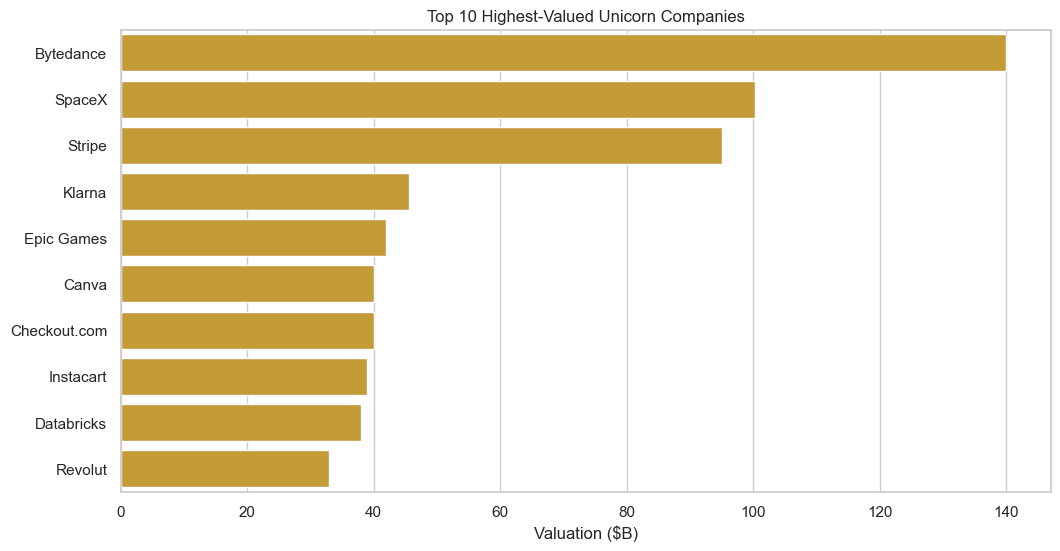

In [12]:
top10 = df.nlargest(10, "valuation")

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="valuation",
    y="Company",
    color="goldenrod"
)

plt.title("Top 10 Highest-Valued Unicorn Companies")
plt.xlabel("Valuation ($B)")
plt.ylabel("")
plt.show()

<h5>2. Number of Companies Reaching Unicorn Status per Year</h5>

The number of firms reaching unicorn status increased sharply over time, with relatively few observations before 2017 and a substantial acceleration from 2018 onward. The most notable spike occurs in **2021**, when the number of new unicorns rises dramatically compared with all previous years.  

This pattern likely reflects exceptionally favorable market conditions during that period, including abundant venture capital liquidity, low interest rates, and strong investor appetite for high-growth technology firms. The decline in 2022 may indicate a normalization of market conditions after the extraordinary expansion of 2021.

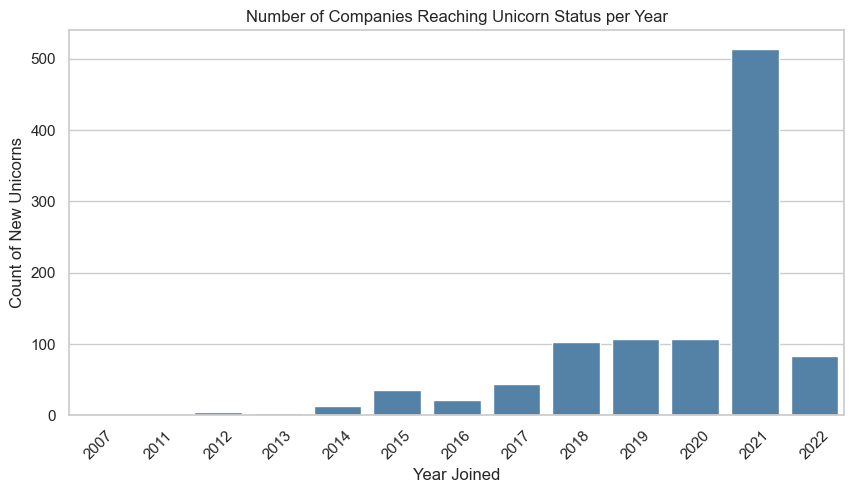

In [13]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="joined_year",
    color="steelblue"
)

plt.title("Number of Companies Reaching Unicorn Status per Year")
plt.xlabel("Year Joined")
plt.ylabel("Count of New Unicorns")
plt.xticks(rotation=45)
plt.show()

<h5>3. Top 15 Countries by Number of Unicorn Companies</h5>

The country distribution reveals a **strong geographic concentration** of unicorn startups. The **United States overwhelmingly dominates the sample**, with far more unicorn companies than any other country, confirming its leading role in the global startup ecosystem. China ranks second, followed by India and the United Kingdom, while all remaining countries contribute comparatively smaller shares.  

This pattern suggests that unicorn creation is highly clustered in economies with **deep capital markets, advanced innovation systems, strong venture capital networks, and large domestic markets**. It also indicates that access to funding and entrepreneurial infrastructure plays a critical role in scaling startups to billion-dollar valuations.

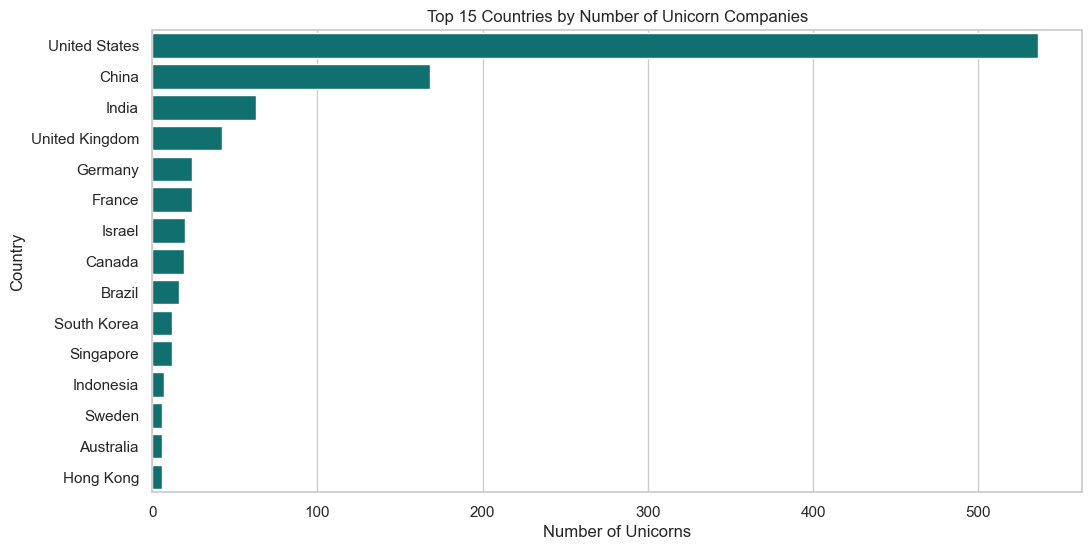

In [14]:
top_countries = df["Country"].value_counts().head(15)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index,
    color="teal"
)

plt.title("Top 15 Countries by Number of Unicorn Companies")
plt.xlabel("Number of Unicorns")
plt.ylabel("Country")
plt.show()

<h5>4. Distribution of Unicorns by Region</h5>

At the regional level, unicorn companies are concentrated primarily in **North America**, followed by **Asia**, with **Europe** occupying a distant third position. Other regions such as Latin America, the Middle East, Oceania, and Africa remain significantly underrepresented.  

These results highlight the uneven global distribution of innovation and venture capital activity. Regions with stronger institutional support, developed financial markets, and mature startup ecosystems tend to generate substantially more unicorn firms. Meanwhile, emerging regions may still face barriers such as limited funding availability, smaller investor networks, or weaker technological infrastructure.

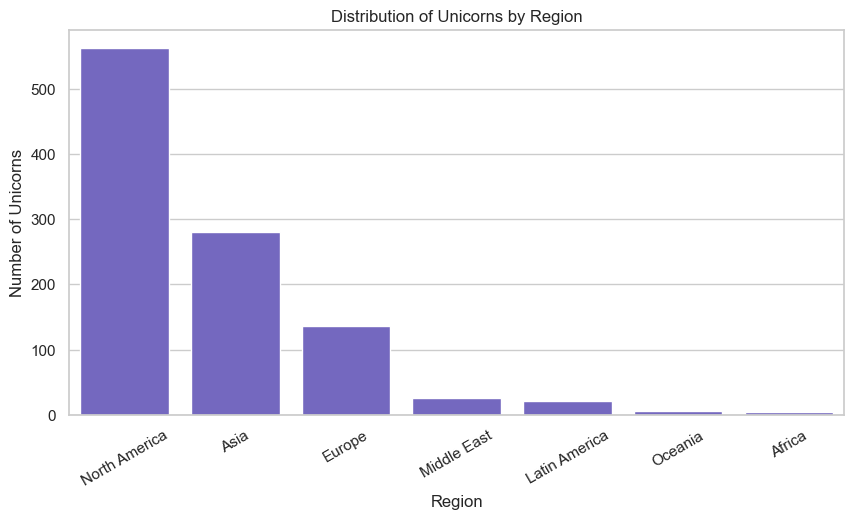

In [15]:
region_counts = df["region"].value_counts()

plt.figure(figsize=(10, 5))

sns.barplot(
    x=region_counts.index,
    y=region_counts.values,
    color="slateblue"
)

plt.title("Distribution of Unicorns by Region")
plt.xlabel("Region")
plt.ylabel("Number of Unicorns")
plt.xticks(rotation=30)
plt.show()

<h5>5. Regional Valuation Summary Statistics</h5>

Although North America has the largest number of unicorn firms, the highest **average valuation** is observed in **Oceania**. However, this result should be interpreted cautiously because the region contains only **six observations**, meaning a few large firms can heavily influence the mean.  

North America, Asia, and Europe show relatively similar average valuations, but Asia records the **highest maximum valuation ($140B)**, indicating the presence of exceptionally large firms. The gap between means and medians across several regions also suggests that valuations are **right-skewed**, where a small number of superstar companies raise the average substantially above the typical firm.

In [16]:
region_valuation = (
    df.groupby("region")["valuation"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        min="min",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        max="max"
    )
    .sort_values("mean", ascending=False)
    .round(2)
)

display(region_valuation)

,count,mean,median,std,min,q25,q75,max
region,,,,,,,,
Oceania,6,8.43,1.55,15.56,1.0,1.12,4.53,40.0
Latin America,22,3.65,1.75,6.51,1.0,1.00,3.08,32.0
North America,562,3.38,1.70,6.90,1.0,1.15,3.35,100.3
Europe,136,3.31,1.55,5.91,1.0,1.05,3.02,45.6
Asia,281,3.11,1.45,8.77,1.0,1.00,2.85,140.0
Middle East,26,2.09,1.50,1.65,1.0,1.00,2.38,7.5
Africa,4,1.57,1.64,0.42,1.0,1.44,1.78,2.0


<h5>6. Log Valuation Distribution by Region</h5>

After applying a logarithmic transformation, valuation differences across regions become easier to compare because the influence of extreme outliers is reduced. The boxplots suggest that the **median valuations across major regions are relatively comparable**.  

However, North America and Asia display a greater number of upper-end outliers, indicating a stronger presence of exceptionally highly valued firms. This suggests that while typical unicorn valuations may be similar across advanced regions, the largest global market leaders are disproportionately concentrated in these ecosystems. Smaller regions exhibit more limited dispersion, reflecting fewer observations and less presence of mega-unicorn firms.

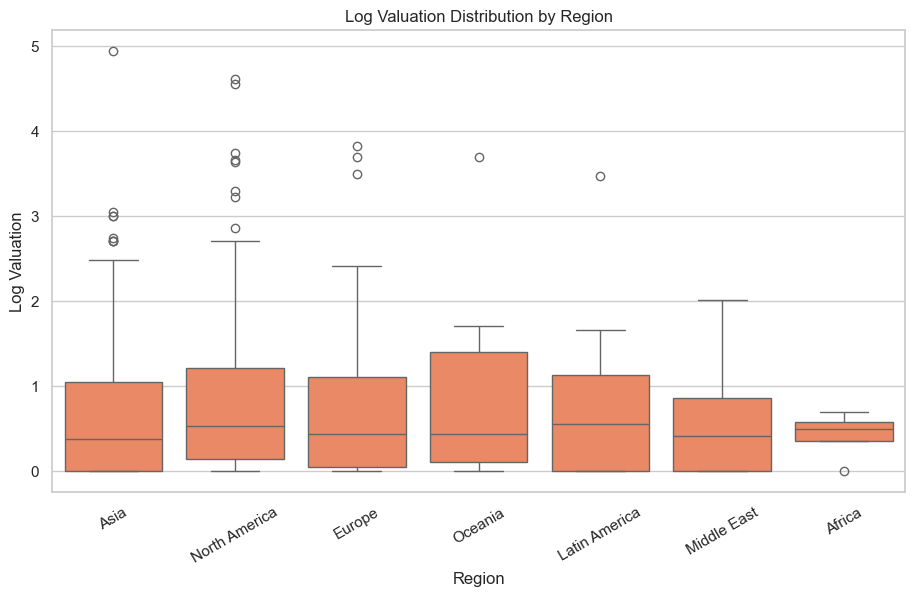

In [17]:
plt.figure(figsize=(11, 6))

sns.boxplot(
    data=df,
    x="region",
    y="log_valuation",
    color="coral"
)

plt.title("Log Valuation Distribution by Region")
plt.xlabel("Region")
plt.ylabel("Log Valuation")
plt.xticks(rotation=30)
plt.show()

<h5>7. Industry Valuation Summary Statistics</h5>

Industry-level summary statistics reveal meaningful differences in both the **frequency of unicorn creation** and the **size of valuations** across sectors. **Fintech** has the largest number of unicorn firms in the dataset, followed closely by **Internet software & services**, confirming the dominant role of digitally scalable business models in the unicorn ecosystem.  

In terms of average valuation, **Artificial intelligence** stands out with one of the highest mean valuations, largely driven by a few exceptionally valuable firms. This is also reflected in its very high standard deviation and maximum valuation of **$140B**, indicating substantial dispersion within the sector.  

The gap between means and medians across several industries suggests that valuations are strongly **right-skewed**, where a small number of superstar firms raise the average above the typical company.


In [18]:
industry_valuation = (
    df.groupby("Industry")["valuation"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        min="min",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        max="max"
    )
    .sort_values("count", ascending=False)
    .round(2)
)

display(industry_valuation.head(15))

,count,mean,median,std,min,q25,q75,max
Industry,,,,,,,,
Fintech,206,3.86,1.90,8.31,1.0,1.10,3.36,95.0
Internet software & services,192,2.90,1.70,3.72,1.0,1.20,3.00,40.0
E-commerce & direct-to-consumer,107,3.04,1.52,3.91,1.0,1.10,3.20,27.0
Artificial intelligence,78,4.08,1.50,15.72,1.0,1.00,2.45,140.0
Other,72,4.44,1.34,12.99,1.0,1.00,2.42,100.3
Health,69,2.65,1.50,2.50,1.0,1.04,3.30,12.6
"Supply chain, logistics, & delivery",57,3.07,1.25,5.77,1.0,1.00,2.30,39.0
Cybersecurity,49,2.50,1.60,2.16,1.0,1.10,2.50,9.0
Data management & analytics,41,3.31,1.62,5.88,1.0,1.15,3.60,38.0


<h5>8. Log Valuation by Major Industries</h5>

After applying the logarithmic transformation, valuation differences across industries become easier to compare because the influence of extreme outliers is reduced. The boxplots suggest that **valuation levels differ across industries**. Some sectors, such as **Fintech** and **Data management & analytics**, display comparatively wider interquartile ranges and greater dispersion, indicating more heterogeneity in firm valuations within these industries.

Several industries, especially **Artificial intelligence** and **Fintech**, also exhibit upper-end outliers, meaning that these sectors contain some exceptionally highly valued companies. This suggests that while many sectors produce unicorns, technology-intensive and data-driven industries are more likely to generate the largest global winners.

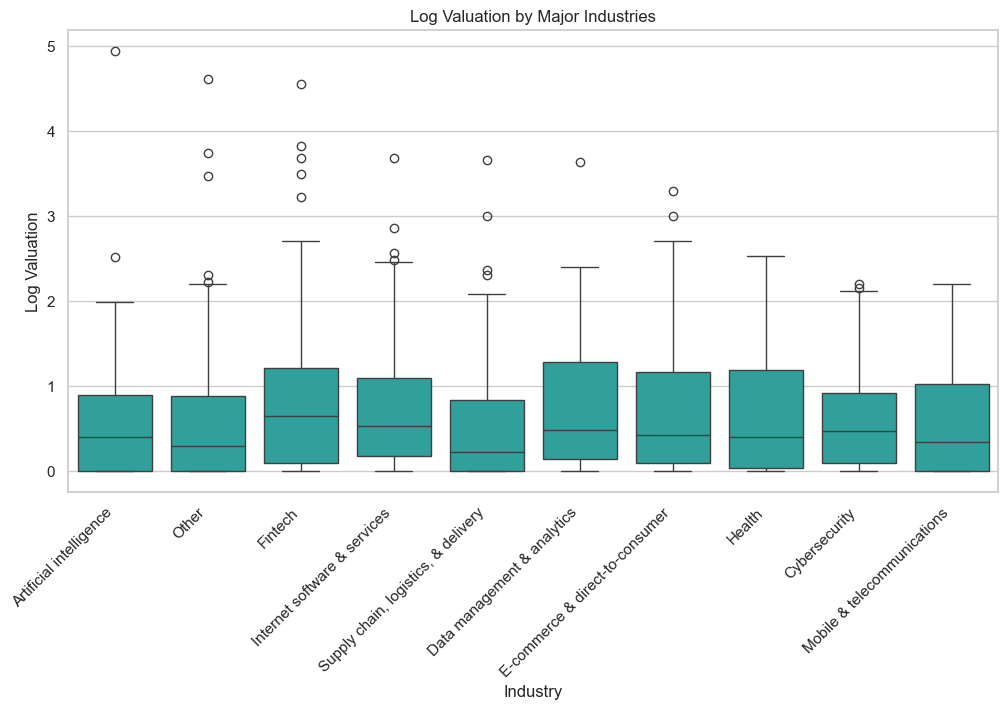

In [19]:
top_ind = df["Industry"].value_counts().head(10).index

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df[df["Industry"].isin(top_ind)],
    x="Industry",
    y="log_valuation",
    color="lightseagreen"
)

plt.title("Log Valuation by Major Industries")
plt.xlabel("Industry")
plt.ylabel("Log Valuation")
plt.xticks(rotation=45, ha="right")
plt.show()

<h5>9. Top Industries Among Unicorn Startups</h5>

When industries are grouped into broader categories, **Software & Data** emerges as the largest segment by a wide margin, followed by **Financial & Business Services** and **Consumer & Commerce**. This indicates that the global unicorn landscape is dominated by firms built around digital products, software platforms, analytics, and scalable online services.  

Traditional capital-intensive sectors such as infrastructure and hardware account for a smaller share of unicorn firms. This pattern suggests that industries with lower marginal costs, faster scalability, and stronger technological spillovers are more likely to generate billion-dollar startups.

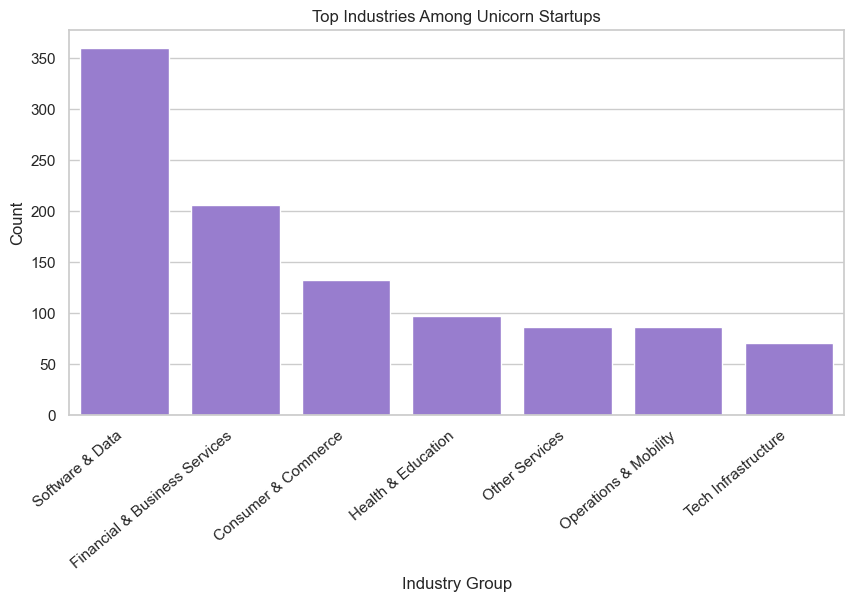

In [20]:
industry_group_counts = df["industry_group"].value_counts()

plt.figure(figsize=(10, 5))

sns.barplot(
    x=industry_group_counts.index,
    y=industry_group_counts.values,
    color="mediumpurple"
)

plt.title("Top Industries Among Unicorn Startups")
plt.xlabel("Industry Group")
plt.ylabel("Count")
plt.xticks(rotation=40, ha="right")
plt.show()

<h5>10. Distribution of Unicorn Valuations</h5>

The valuation distribution is **strongly right-skewed**, with the vast majority of unicorn firms clustered at relatively low valuation levels and a small number of companies reaching extremely high values. Most observations appear concentrated close to the minimum unicorn threshold, while only a few firms exceed $20B or more.  This indicates that although all firms in the sample are valued above $1 billion, the unicorn category remains highly heterogeneous.

<h5>11. Distribution of Log Unicorn Valuations</h5>

Since the raw valuation distribution is strongly right-skewed, the logarithmic transformation is used to reduce the influence of extremely highly valued companies and make the dependent variable more suitable for linear regression.

After applying the log transformation, the distribution of company valuation becomes more compressed and less dominated by extreme observations. Therefore, `log_valuation` is used as the dependent variable in the econometric model instead of raw `valuation`.

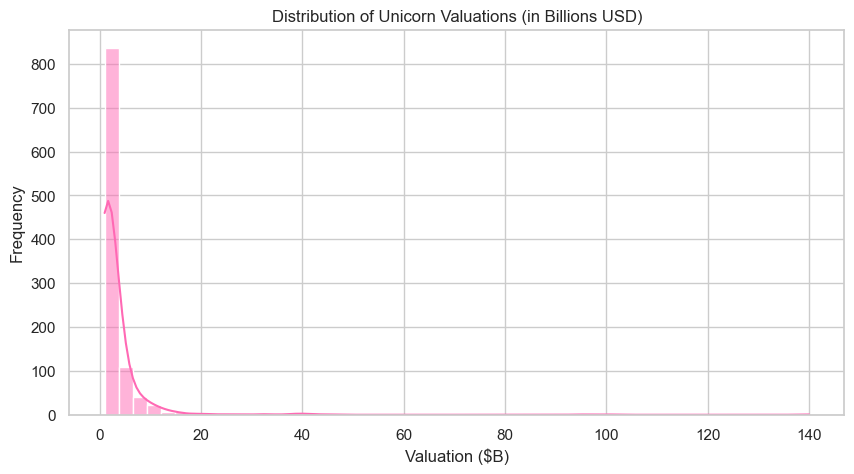

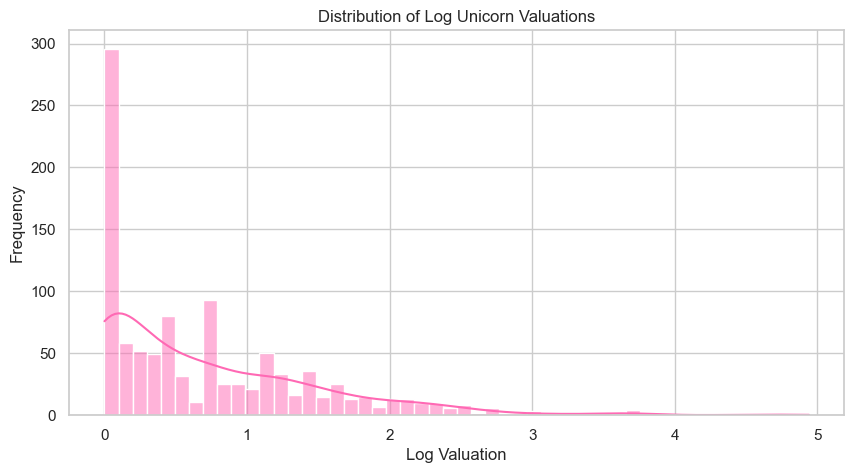

In [21]:
plt.figure(figsize=(10, 5))
sns.histplot(df["valuation"], bins=50, kde=True, color="hotpink")
plt.title("Distribution of Unicorn Valuations (in Billions USD)")
plt.xlabel("Valuation ($B)")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(df["log_valuation"], bins=50, kde=True, color="hotpink")
plt.title("Distribution of Log Unicorn Valuations")
plt.xlabel("Log Valuation")
plt.ylabel("Frequency")
plt.show()

<h5>11. Distribution of Deal Terms</h5>

The distribution of deal terms is positively skewed, with most unicorn companies having a relatively small number of financing rounds. The highest concentration of observations lies between approximately **2 and 4 deal terms**, indicating that many firms reach unicorn status after a limited number of funding events.  

A smaller number of companies exhibit substantially more deal rounds, creating a long right tail. This suggests that while some startups scale efficiently with fewer financing stages, others require repeated fundraising before achieving billion-dollar valuations.

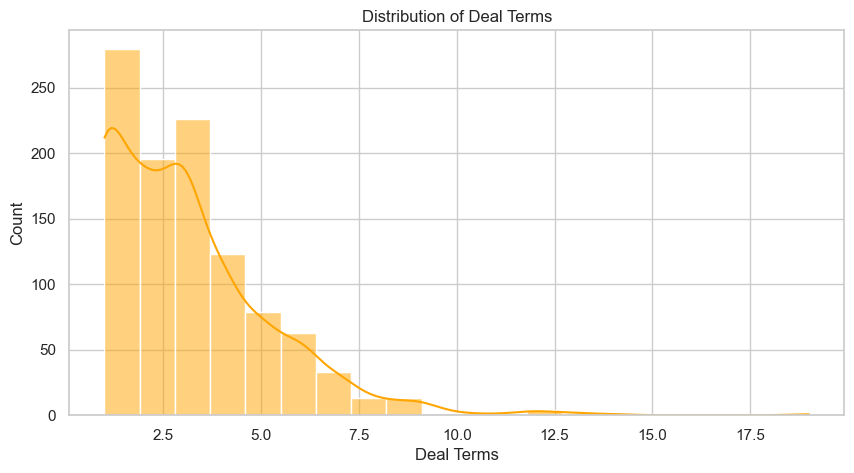

In [22]:
plt.figure(figsize=(10,5))
sns.histplot(df["deal_terms"], bins=20, kde=True, color="orange")
plt.title("Distribution of Deal Terms")
plt.xlabel("Deal Terms")
plt.show()

<h5>12. Distribution of Number of Investors</h5>

The number of investors is also right-skewed, with most unicorn firms backed by a moderate number of investors. The largest concentration appears roughly between **5 and 20 investors**, indicating that many successful startups attract diversified but not excessively large investor groups.  

A limited number of firms have very high investor counts, exceeding 40 or even more. This may reflect later-stage companies with broad institutional participation or firms that completed multiple funding rounds involving many stakeholders.

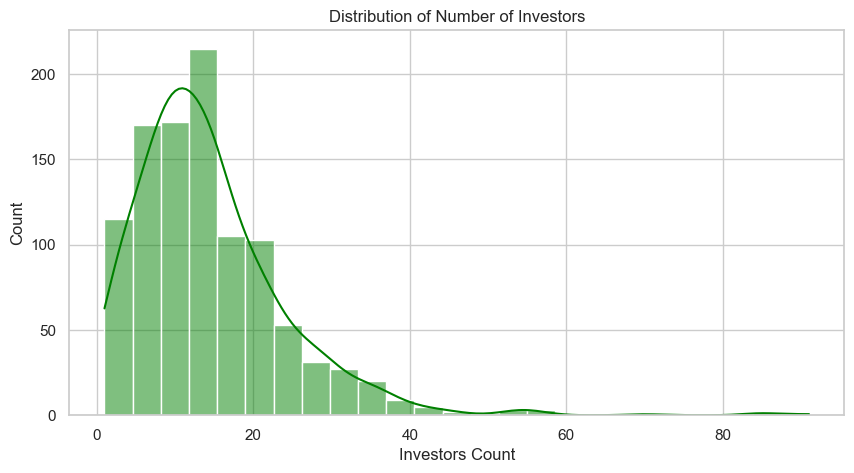

In [23]:
plt.figure(figsize=(10,5))
sns.histplot(df["investors_count"], bins=25, kde=True, color="green")
plt.title("Distribution of Number of Investors")
plt.xlabel("Investors Count")
plt.show()

<h5>13. Distribution of Time Required to Reach Unicorn Status</h5>

The distribution of time required to become a unicorn shows that most firms achieve unicorn status within approximately **3 to 10 years** after founding. This suggests that successful startups typically scale relatively quickly once product-market fit and financing momentum are established.  

However, the distribution has a long right tail, indicating that some companies required substantially more time to reach the $1 billion threshold. Therefore, while rapid growth is common, there is no single timeline for unicorn success.

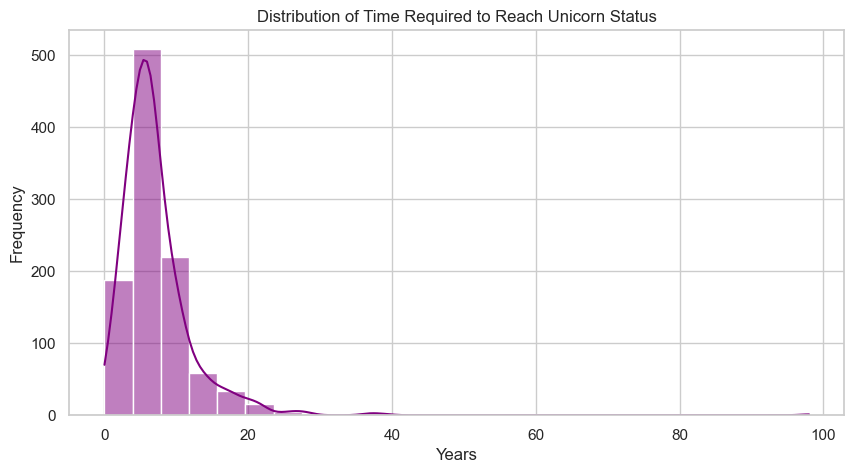

In [24]:
plt.figure(figsize=(10,5))
sns.histplot(df["age_to_unicorn"], bins=25, kde=True, color="purple")
plt.title("Distribution of Time Required to Reach Unicorn Status")
plt.xlabel("Years")
plt.ylabel("Frequency")
plt.show()

<h5>14. Distribution of Total Raised</h5>

The raw distribution of total capital raised is strongly right-skewed. Most unicorn companies raised comparatively modest funding amounts, while a small number of firms secured exceptionally large levels of capital.  

This indicates that unicorn status can be achieved through different financing paths: some firms rely on moderate funding combined with efficient growth, whereas others accumulate very large capital inflows. The presence of extreme funding outliers supports the use of logarithmic transformation in the econometric analysis.

<h5>15. Distribution of Log Total Raised</h5>

After applying the logarithmic transformation, the distribution of total raised becomes substantially more symmetric and closer to a bell-shaped form. As a result, **log_total_raised** is more suitable for regression modeling.

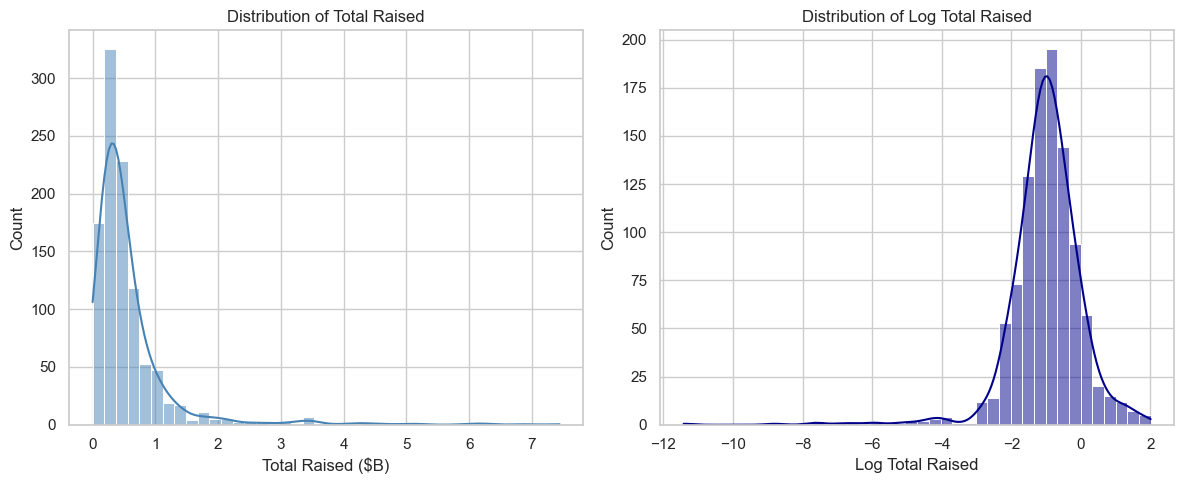

In [25]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df["total_raised"], bins=40, kde=True, color="steelblue")
plt.title("Distribution of Total Raised")
plt.xlabel("Total Raised ($B)")

plt.subplot(1,2,2)
sns.histplot(df["log_total_raised"], bins=40, kde=True, color="darkblue")
plt.title("Distribution of Log Total Raised")
plt.xlabel("Log Total Raised")

plt.tight_layout()
plt.show()

<h5>16. Total Raised vs Valuation</h5>

The scatterplot suggests a **positive relationship** between the total amount of capital raised and company valuation. In general, firms that raised more funding tend to have higher valuations, although the relationship is not perfectly linear. The scatterplot also reveals several **clear outliers**, where a small number of firms combine exceptionally high funding levels and extremely large valuations. These observations likely correspond to global market leaders such as Bytedance, SpaceX, and Stripe. 

There is also substantial dispersion, meaning that companies with similar funding levels may still have very different valuations. This implies that while access to capital is an important determinant of valuation, other factors such as industry, geography, business model, or growth expectations also play a significant role.

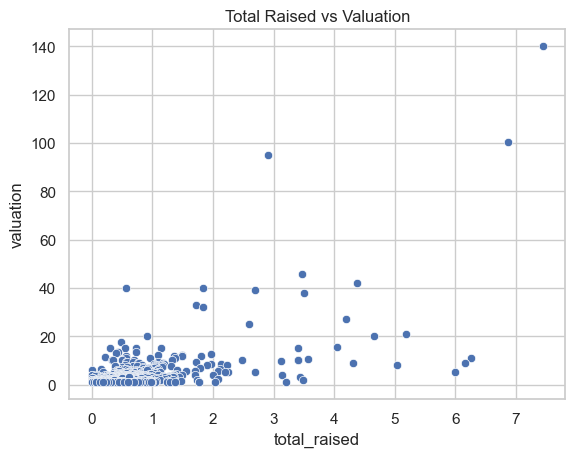

In [26]:
sns.scatterplot(x="total_raised", y="valuation", data=df)
plt.title("Total Raised vs Valuation")
plt.show()

<h5>17. Correlation Matrix</h5>

The correlation matrix confirms that **total raised** has the strongest positive association with valuation (**0.62**), making it one of the most relevant explanatory variables in the dataset. This supports the hypothesis that greater investor financing is linked to higher startup valuations.  

More moderate positive correlations are observed between valuation and **deal terms (0.36)**, as well as **investors count (0.23)**, suggesting that broader financing activity may also contribute to firm value.  

By contrast, **age_to_unicorn** shows almost no correlation with valuation, indicating that the speed at which a company reaches unicorn status may not have a strong direct linear relationship with its final valuation in the raw data.  

Overall, the matrix does not indicate severe multicollinearity among the independent variables, which is favorable for regression analysis.

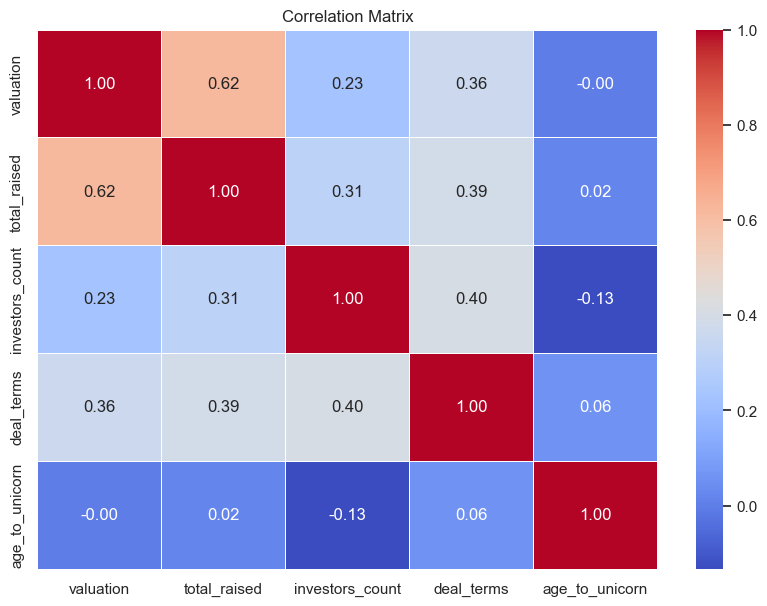

In [27]:
corr_cols = ["valuation", "total_raised", "investors_count", "deal_terms", "age_to_unicorn"]


plt.figure(figsize=(10, 7))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

## 5. Model Specification

The empirical analysis is based on a log-linear OLS regression model that relates unicorn company valuation to financial, structural, and geographic characteristics.
The estimated model is specified as follows:

$$
\begin{aligned}
\ln(\text{Valuation}_i) =\;&
\beta_0
+ \beta_1 \ln(\text{TotalRaised}_i)
+ \beta_2\,\text{InvestorsCount}_i
+ \beta_3\,\text{DealTerms}_i
+ \beta_4\,\text{Age}_i \\
&+ \gamma_1\,\text{SoftwareData}_i
+ \gamma_2\,\text{FinancialBusiness}_i
+ \gamma_3\,\text{ConsumerCommerce}_i \\
&+ \delta_1\,\text{SiliconValley}_i
+ \delta_2\,\text{EastCoastUSA}_i
+ \delta_3\,\text{OtherUSA}_i
+ \delta_4\,\text{China}_i
+ \delta_5\,\text{Europe}_i \\
&+ \beta_5\!\left(\ln(\text{TotalRaised}_i)\cdot\text{SiliconValley}_i\right)
+ \beta_6\!\left(\ln(\text{TotalRaised}_i)\cdot\text{EastCoastUSA}_i\right) \\
&+ \beta_7\!\left(\ln(\text{TotalRaised}_i)\cdot\text{OtherUSA}_i\right)
+ \beta_8\!\left(\ln(\text{TotalRaised}_i)\cdot\text{China}_i\right) \\
&+ \beta_9\!\left(\ln(\text{TotalRaised}_i)\cdot\text{Europe}_i\right)
+ u_i
\end{aligned}
$$

where $i$ indexes individual companies.

**Dependent variable.** $\ln(\text{Valuation}_i)$ is the natural logarithm of company valuation in billions USD. This transformation addresses the strong right-skewness of the valuation distribution and allows interpretation of coefficients in percentage terms. Since all unicorn companies have valuation $\geq \$1B$, the transformed variable is non-negative by construction.

**Continuous predictors:**

- $\ln(\text{TotalRaised}_i)$ — natural logarithm of total funding raised (in billions USD), yielding a log-log specification where $\beta_1$ is interpreted as an elasticity: a 1% increase in total funding raised is associated with a $\beta_1\%$ change in valuation;
- $\text{InvestorsCount}_i$ — number of investors backing company $i$, reflecting breadth of investor support and potential signaling effects;
- $\text{DealTerms}_i$ — number of funding deals concluded by company $i$, capturing the intensity of financing activity;
- $\text{Age}_i$ — years between founding and unicorn status, capturing differences in growth dynamics across firms.

**Industry dummies** (base group = Other):

- $\text{SoftwareData}_i$ — AI, Cybersecurity, Internet software \& services, Data management;
- $\text{FinancialBusiness}_i$ — Fintech;
- $\text{ConsumerCommerce}_i$ — E-commerce, Consumer \& retail.

**Location dummies** (base group = Other — all remaining countries including India, Israel, Brazil, Singapore, and others):

- $\text{SiliconValley}_i$ — equal to 1 if the company is headquartered in San Francisco, Mountain View, Palo Alto, Redwood City, or San Mateo;
- $\text{EastCoastUSA}_i$ — equal to 1 if the company is headquartered in New York or Boston;
- $\text{OtherUSA}_i$ — equal to 1 if the company is US-based but located outside Silicon Valley and the East Coast;
- $\text{China}_i$ — equal to 1 if the company is headquartered in China;
- $\text{Europe}_i$ — equal to 1 if the company is headquartered in a European country.

By construction, the five location dummies are mutually exclusive and exhaustive (within the non-base group), ensuring no overlap and avoiding multicollinearity.

**Interaction terms** capture whether the effect of total funding on valuation differs across geographies:

$$
\beta_5\!\left(\ln(\text{TotalRaised}_i)\cdot\text{SiliconValley}_i\right), \quad
\beta_6\!\left(\ln(\text{TotalRaised}_i)\cdot\text{EastCoastUSA}_i\right), \quad
\beta_7\!\left(\ln(\text{TotalRaised}_i)\cdot\text{OtherUSA}_i\right)
$$
$$
\beta_8\!\left(\ln(\text{TotalRaised}_i)\cdot\text{China}_i\right), \quad
\beta_9\!\left(\ln(\text{TotalRaised}_i)\cdot\text{Europe}_i\right)
$$

The marginal effect of $\ln(\text{TotalRaised})$ on $\ln(\text{Valuation})$ depends on the location of the firm. For example, for a Silicon Valley company: $\beta_1 + \beta_5$; for an East Coast company: $\beta_1 + \beta_6$; for a Chinese company: $\beta_1 + \beta_8$. For the base group (Other), the marginal effect is simply $\beta_1$.

**Error term.** $u_i$ captures all unobserved factors affecting valuation not included in the model. Heteroskedasticity-robust standard errors (HC3) are used throughout to ensure valid inference.

### Additional Model Preparation Based on EDA

After the initial data cleaning and preprocessing, several additional adjustments were implemented at the model specification stage based on the exploratory data analysis.

**Outlier removal.** Three extremely high-valued companies identified during EDA — specifically ByteDance, SpaceX, and Stripe — are excluded from the final regression sample. These firms represent clear statistical outliers with the potential to exert disproportionate leverage on coefficient estimates and distort inference for the broader population of unicorns.

**Geographic location groups.** Rather than using country-level dummies, we construct five mutually exclusive location groups designed to capture economically meaningful geographic variation while maintaining sample balance across categories. The United States is split into three sub-groups: Silicon Valley (San Francisco, Mountain View, Palo Alto, Redwood City, San Mateo), East Coast USA (New York, Boston), and Other USA (all remaining US cities). China and Europe are retained as separate groups. All remaining countries — including India, Israel, Brazil, Singapore, and others — are pooled into the **Other** category, which serves as the baseline group. This grouping reflects both the economic logic of the venture capital ecosystem and the distributional properties of the sample, with each group representing between 10% and 22% of observations.

**Industry groups.** Industries are collapsed into four broader, economically meaningful categories: Software \& Data (AI, Cybersecurity, Internet software \& services, Data management \& analytics), Financial \& Business Services (Fintech), Consumer \& Commerce (E-commerce, Consumer \& retail), and Other. The **Other** category serves as the reference group in the regression. This grouping reduces the number of dummy variables while preserving economically interpretable distinctions across sectors.

**Interaction terms.** Interaction terms between $\ln(\text{TotalRaised})$ and each geographic dummy are included in the model. These variables test whether the marginal effect of capital accumulation on valuation differs systematically across major locations — for instance, whether an additional dollar of funding yields a higher valuation premium in Silicon Valley compared to Europe or China.

In [50]:
# PREPARE DATA
display(df.head())

# use existing dataframe (no df2 needed)
df.columns = df.columns.str.strip()

# ensure numeric columns needed for regression are numeric
numeric_cols = [
    "valuation",
    "total_raised",
    "investors_count",
    "deal_terms",
    "log_valuation",
    "log_total_raised",
    "age_to_unicorn"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# reuse age created in preprocessing
df["age"] = df["age_to_unicorn"]

# keep only valid observations
df = df[(df["valuation"] > 0) & (df["total_raised"] >= 0)].copy()

# REMOVE SELECTED COMPANIES
companies_to_remove = ["Bytedance", "SpaceX", "Stripe"]
print("Rows to remove:")
print(df[df["Company"].isin(companies_to_remove)][
    ["Company", "valuation", "Country", "Industry"]
])
df = df[~df["Company"].isin(companies_to_remove)].copy()

#usa dummies and region groups
df["Country"] = df["Country"].astype(str).str.strip()
df["City"]    = df["City"].astype(str).str.strip()

silicon_valley_cities = [
    "San Francisco", "Mountain View", "Palo Alto",
    "Redwood City", "San Mateo"
]
east_coast_cities = ["New York", "Boston"]

europe_countries = [
    "United Kingdom", "Germany", "France", "Sweden", "Netherlands",
    "Switzerland", "Spain", "Finland", "Denmark", "Norway",
    "Austria", "Belgium", "Portugal", "Estonia", "Lithuania",
    "Ireland", "Italy", "Luxembourg", "Croatia", "Czech Republic"
]

def group_location(row):
    city    = row["City"]
    country = row["Country"]
    if city in silicon_valley_cities:        return "Silicon_Valley"
    elif city in east_coast_cities:          return "East_Coast_USA"
    elif country == "United States":         return "Other_USA"
    elif country == "China":                 return "China"
    elif country in europe_countries:        return "Europe"
    else:                                    return "Other"

df["location_group"] = df.apply(group_location, axis=1)

print("\n=== Location Group Distribution ===")
print(df["location_group"].value_counts())

# dummies (base group = Other)
df["silicon_valley"]  = (df["location_group"] == "Silicon_Valley").astype(int)
df["east_coast_usa"]  = (df["location_group"] == "East_Coast_USA").astype(int)
df["other_usa"]       = (df["location_group"] == "Other_USA").astype(int)
df["china"]           = (df["location_group"] == "China").astype(int)
df["europe"]          = (df["location_group"] == "Europe").astype(int)

# CREATE INDUSTRY GROUPS
df["Industry"] = df["Industry"].astype(str).str.strip()

def group_industry(ind):
    if ind in [
        "Data management & analytics",
        "Internet software & services",
        "Artificial intelligence",
        "Cybersecurity"
    ]:
        return "Software_Data"
    elif ind in ["Fintech"]:
        return "Financial_Business_Services"
    elif ind in [
        "E-commerce & direct-to-consumer",
        "Consumer & retail"
    ]:
        return "Consumer_Commerce"
    else:
        return "Other"

df["industry_group"] = df["Industry"].apply(group_industry)

# base group = Other
df["ind_software_data"]      = (df["industry_group"] == "Software_Data").astype(int)
df["ind_financial_business"] = (df["industry_group"] == "Financial_Business_Services").astype(int)
df["ind_consumer_commerce"]  = (df["industry_group"] == "Consumer_Commerce").astype(int)

# CREATE INTERACTION TERMS
df["log_totalraised_x_sv"]         = df["log_total_raised"] * df["silicon_valley"]
df["log_totalraised_x_east_coast"]  = df["log_total_raised"] * df["east_coast_usa"]
df["log_totalraised_x_other_usa"]   = df["log_total_raised"] * df["other_usa"]
df["log_totalraised_x_china"]       = df["log_total_raised"] * df["china"]
df["log_totalraised_x_europe"]      = df["log_total_raised"] * df["europe"]

# =========================
# KEEP ONLY MODEL VARIABLES
# =========================
model_vars = [
    "log_valuation",
    "log_total_raised",
    "investors_count",
    "deal_terms",
    "age",
    "ind_software_data",
    "ind_financial_business",
    "ind_consumer_commerce",
    "silicon_valley",
    "east_coast_usa",
    "other_usa",
    "china",
    "europe",
    "log_totalraised_x_sv",
    "log_totalraised_x_east_coast",
    "log_totalraised_x_other_usa",
    "log_totalraised_x_china",
    "log_totalraised_x_europe"
]

df_model = df[model_vars].dropna().copy()
print("\nRemaining observations in model:", len(df_model))

# RUN MODEL
formula = """
log_valuation ~ log_total_raised
              + investors_count
              + deal_terms
              + age
              + ind_software_data
              + ind_financial_business
              + ind_consumer_commerce
              + silicon_valley
              + east_coast_usa
              + other_usa
              + china
              + europe
              + log_totalraised_x_sv
              + log_totalraised_x_east_coast
              + log_totalraised_x_other_usa
              + log_totalraised_x_china
              + log_totalraised_x_europe
"""

model = smf.ols(formula=formula, data=df_model).fit(cov_type="HC3")
print(model.summary())

,Sno,Company,valuation,date_joined,Country,City,Industry,investors,founded_year,total_raised,financial_stage,investors_count,deal_terms,portfolio_exits,Unicorn Nest website link,fund_structure,social_media_presence,joined_year,age_to_unicorn,is_us,is_china,industry_group,region,log_valuation,log_total_raised,age,location_group,usa,china,india,is_silicon_valley,ind_software_data,ind_financial_business,ind_consumer_commerce,log_totalraised_x_usa,log_totalraised_x_china,log_totalraised_x_india,log_totalraised_x_sv,silicon_valley,east_coast_usa,other_usa,europe,log_totalraised_x_east_coast,log_totalraised_x_other_usa,log_totalraised_x_europe
3,4,Klarna,45.6,2011-12-12,Sweden,Stockholm,Fintech,"Institutional Venture Partners, Sequoia Capita...",2005.0,3.47200,Acquired,56.0,13.0,1.0,https://unicorn-nest.com/funds/21212/,VC,1.0,2011,6.0,0,0,Financial_Business_Services,Europe,3.819908,1.244731,6.0,Europe,0,0,0,0,0,1,0,0.000000,0.0,0.0,0.000000,0,0,0,1,0.0,0.000000,1.244731
4,5,Epic Games,42.0,2018-10-26,United States,Cary,Other,"Tencent Holdings, KKR, Smash Ventures",1991.0,4.37700,Acquired,25.0,5.0,2.0,https://unicorn-nest.com/funds/406-ventures/,VC,1.0,2018,27.0,1,0,Other,North America,3.737670,1.476364,27.0,Other_USA,1,0,0,0,0,0,0,1.476364,0.0,0.0,0.000000,0,0,1,0,0.0,1.476364,0.000000
5,6,Canva,40.0,2018-01-08,Australia,Surry Hills,Internet software & services,"Sequoia Capital China, Blackbird Ventures, Mat...",2012.0,0.57126,NaN,26.0,8.0,NaN,https://unicorn-nest.com/funds/212media/,VC,1.0,2018,6.0,0,0,Software_Data,Oceania,3.688879,-0.559909,6.0,Other,0,0,0,0,1,0,0,-0.000000,-0.0,-0.0,-0.000000,0,0,0,0,-0.0,-0.000000,-0.000000
6,7,Checkout.com,40.0,2019-05-02,United Kingdom,London,Fintech,"Tiger Global Management, Insight Partners, DST...",2012.0,1.83000,NaN,15.0,4.0,NaN,https://unicorn-nest.com/funds/ventures/,VC,1.0,2019,7.0,0,0,Financial_Business_Services,Europe,3.688879,0.604317,7.0,Europe,0,0,0,0,0,1,0,0.000000,0.0,0.0,0.000000,0,0,0,1,0.0,0.000000,0.604317
7,8,Instacart,39.0,2014-12-30,United States,San Francisco,"Supply chain, logistics, & delivery","Khosla Ventures, Kleiner Perkins Caufield & By...",2012.0,2.68600,NaN,29.0,12.0,NaN,https://unicorn-nest.com/funds/adm-ventures/,VC,1.0,2014,2.0,1,0,Other,North America,3.663562,0.988053,2.0,Silicon_Valley,1,0,0,1,0,0,0,0.988053,0.0,0.0,0.988053,1,0,0,0,0.0,0.000000,0.000000


Rows to remove:
Empty DataFrame
Columns: [Company, valuation, Country, Industry]
Index: []

=== Location Group Distribution ===
location_group
Other_USA         226
Other             197
Silicon_Valley    196
China             167
Europe            136
East_Coast_USA    112
Name: count, dtype: int64

Remaining observations in model: 1034
                            OLS Regression Results                            
Dep. Variable:          log_valuation   R-squared:                       0.318
Model:                            OLS   Adj. R-squared:                  0.307
Method:                 Least Squares   F-statistic:                     13.53
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           4.67e-35
Time:                        18:56:03   Log-Likelihood:                -968.42
No. Observations:                1034   AIC:                             1973.
Df Residuals:                    1016   BIC:                             2062.
Df Model:                   

/var/folders/8q/sncmbnq51r51c85n5l8ymx600000gn/T/ipykernel_68216/2104523321.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


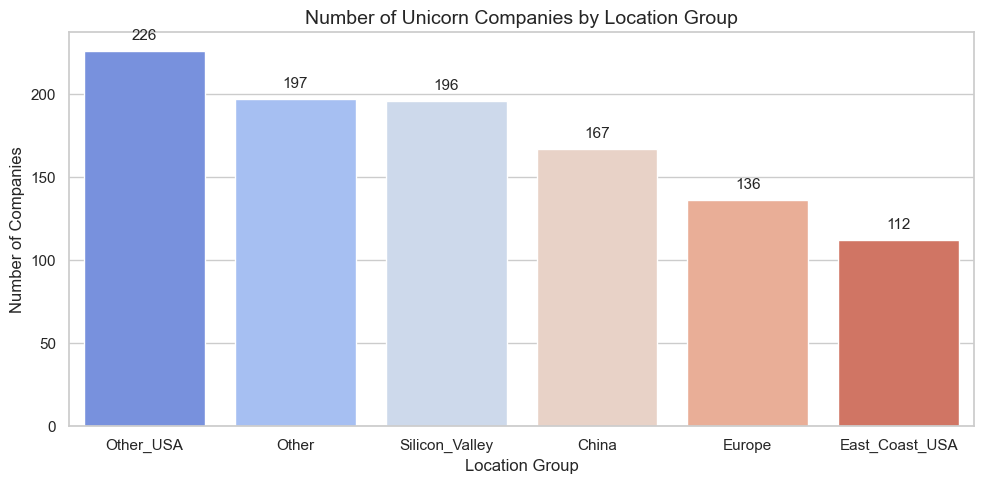

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

location_counts = df["location_group"].value_counts().reset_index()
location_counts.columns = ["Location Group", "Count"]

# sort by count descending
location_counts = location_counts.sort_values("Count", ascending=False)

plt.figure(figsize=(10, 5))
bars = sns.barplot(
    data=location_counts,
    x="Location Group",
    y="Count",
    palette="coolwarm"
)

# add count labels on top of bars
for bar, count in zip(bars.patches, location_counts["Count"]):
    bars.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        str(count),
        ha="center", va="bottom", fontsize=11
    )

plt.title("Number of Unicorn Companies by Location Group", fontsize=14)
plt.xlabel("Location Group")
plt.ylabel("Number of Companies")
plt.tight_layout()
plt.show()

/var/folders/8q/sncmbnq51r51c85n5l8ymx600000gn/T/ipykernel_68216/2219263940.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


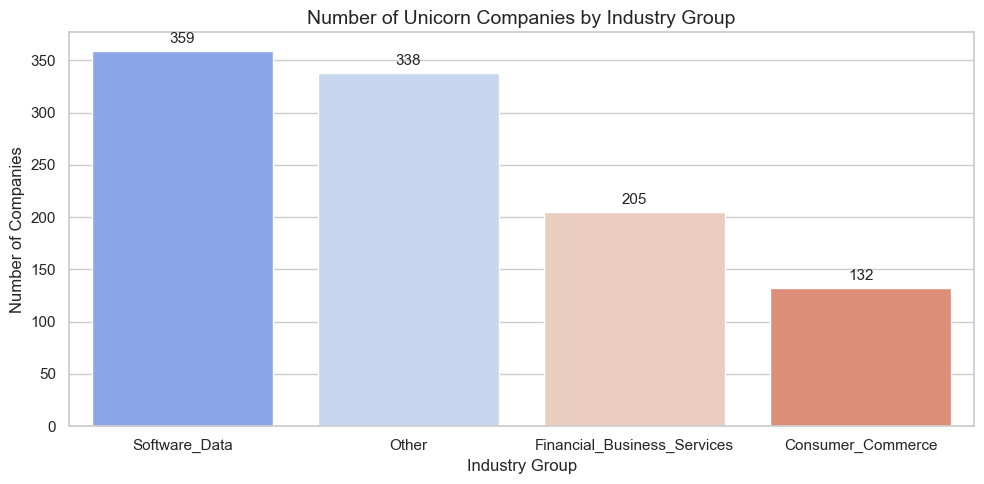

In [52]:
industry_counts = df["industry_group"].value_counts().reset_index()
industry_counts.columns = ["Industry Group", "Count"]

industry_counts = industry_counts.sort_values("Count", ascending=False)

plt.figure(figsize=(10, 5))
bars = sns.barplot(
    data=industry_counts,
    x="Industry Group",
    y="Count",
    palette="coolwarm"
)

for bar, count in zip(bars.patches, industry_counts["Count"]):
    bars.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        str(count),
        ha="center", va="bottom", fontsize=11
    )

plt.title("Number of Unicorn Companies by Industry Group", fontsize=14)
plt.xlabel("Industry Group")
plt.ylabel("Number of Companies")
plt.tight_layout()
plt.show()

### Why exactly such industries and location distribution?


#### Geographic Location Groups

To capture geographic heterogeneity in unicorn valuations, we construct five mutually exclusive location dummies, with **Other** serving as the base group. The grouping is motivated by two considerations: **economic logic** and **sample balance**.

From an economic standpoint, geography is not arbitrary in the venture capital ecosystem. Silicon Valley and the US East Coast (New York, Boston) represent the two dominant global hubs of venture capital activity, characterized by dense investor networks, high deal flow, and premium valuations. China constitutes a distinct market with state-linked capital and platform-driven business models. European unicorns operate under different regulatory and funding environments. The remaining countries — including India, Israel, Brazil, Singapore, and others — are grouped into **Other**, which serves as the baseline against which all location effects are measured.

From a **sample balance** perspective, the grouping ensures that each category contains a meaningful share of observations, avoiding sparse cells that could inflate standard errors:

| Location Group | N | Share |
|---|---|---|
| Other\_USA | 226 | ~21.9% |
| Silicon\_Valley | 196 | ~19.0% |
| Other (base) | 159 | ~15.4% |
| China | 151 | ~14.6% |
| Europe | 127 | ~12.3% |
| East\_Coast\_USA | 112 | ~10.8% |

This distribution is reasonably balanced across groups, with each representing between 10% and 22% of the sample.

#### Industry Groups

Similarly, we collapse the original 15 industry categories into four mutually exclusive groups, with **Other** as the base:

- **Software \& Data** — Artificial intelligence, Internet software \& services, Data management \& analytics, Cybersecurity. These are grouped together as they share platform-based, asset-light business models with high scalability.
- **Financial \& Business Services** — Fintech only. Retained as a standalone group due to its size (the largest single industry in the dataset) and distinct investor valuation logic.
- **Consumer \& Commerce** — E-commerce \& direct-to-consumer, Consumer \& retail. Grouped by shared demand-side characteristics and consumer market exposure.
- **Other (base)** — Supply chain, Health, Edtech, Hardware, Travel, Telecommunications, and remaining categories.

The resulting distribution again achieves rough balance across groups, with no single group dominating the sample, which supports stable coefficient estimation for the industry dummies.

## 5. Hypotheses and objectives description

### Variables Introduction
To test our hypotheses, we examine the relationships between our dependent variable and several independent variables:

* **Dependent Variable ($y$):**  $\ln(\text{Valuation})$. We use a log transformation to account for the highly right-skewed nature of startup valuations.
* **Independent Variables ($x$):** Total funding raised, the company's age at the time of becoming a unicorn (Date Joined minus Year Founded), dummy variables for specific industries and locations, and the total count of backing investors.



### Statistical Meaning and Formulation of Hypotheses

#### **Task 1: Assess the relationship between capital accumulation and unicorn valuation.**
* **Variable Tested:** $X_1 =$ Total Raised (B). Let $\beta_1$ be its coefficient.
* **Hypothesis:** Companies that raise more total funding tend to have higher valuations.
* **Mathematical Formulation:**
  * $H_0: \beta_1 \le 0$ (Total funding has no effect or a negative effect on valuation)
  * $H_1: \beta_1 > 0$ (Total funding has a positive effect on valuation)

Here the right-tailed t-test is applied.

In [53]:
 
beta_hat = model.params["log_total_raised"]
se_beta  = model.bse["log_total_raised"]
t_stat   = beta_hat / se_beta
df_resid = model.df_resid
 
# right-tailed p-value
p_value_one_sided = 1 - t.cdf(t_stat, df_resid)
 
# critical value at α = 0.05
alpha = 0.05
t_critical = t.ppf(1 - alpha, df_resid)
 
print(f"Coefficient (β̂1):      {beta_hat:.6f}")
print(f"Robust Std. Error:      {se_beta:.6f}")
print(f"t-statistic:            {t_stat:.4f}")
print(f"t-critical (α=0.05):   {t_critical:.4f}")
print(f"One-sided p-value:      {p_value_one_sided:.6f}")
print(f"Degrees of freedom:     {int(df_resid)}")

 

Coefficient (β̂1):      0.249870
Robust Std. Error:      0.096923
t-statistic:            2.5780
t-critical (α=0.05):   1.6464
One-sided p-value:      0.005038
Degrees of freedom:     1016


#### Decision Rule

At the 5% significance level:
- Reject $H_0$ if the one-sided p-value < 0.05
- Otherwise, fail to reject $H_0$

From the regression results:
- Estimated coefficient: $\hat{\beta}_1 = 0.249870$
- Robust standard error: $0.096923$
- t-statistic: $2.5780$
- t-critical ($\alpha = 0.05$): $1.6464$
- One-sided p-value: $0.005038$

Since:

$$0.005038 < 0.05$$

the null hypothesis is rejected at the 5% significance level.

#### Conclusion

There is strong statistical evidence that total funding raised has a significant positive effect on unicorn company valuation, holding all other factors constant.

Because the model is log-log, the coefficient represents an elasticity. Specifically:

$$\hat{\beta}_1 = 0.2499 \implies \text{a 1\% increase in total funding raised is associated with a } 0.25\% \text{ increase in valuation}$$

This result is consistent with the hypothesis that capital accumulation is a key driver of unicorn valuation. Companies that successfully raise larger amounts of funding signal stronger growth prospects and investor confidence, which is directly reflected in higher market valuations.

#### **Task 2: Analyze the relationship between company age and unicorn valuation.**
* **Variable Tested:** $x_2 =$ Age at unicorn status (years). Let $\beta_2$ be its coefficient.
* **Question:** Does the age of a company at the time of becoming a unicorn affect its valuation level?
* **Mathematical Formulation:**
  * $H_0: \beta_2 = 0$ (The age of the company has no effect on its valuation)
  * $H_1: \beta_2 \neq 0$ (The age of the company significantly affects its valuation, either positively or negatively)

Here the two-sided t-test is used.

In [40]:
beta_hat = model.params["age"]
se_beta  = model.bse["age"]
t_stat   = beta_hat / se_beta
df_resid = model.df_resid

# two-sided p-value
p_value_two_sided = 2 * (1 - t.cdf(abs(t_stat), df_resid))

# critical value at α = 0.05, two-sided
alpha = 0.05
t_critical = t.ppf(1 - alpha/2, df_resid)

print(f"Coefficient (β̂2):      {beta_hat:.6f}")
print(f"Robust Std. Error:      {se_beta:.6f}")
print(f"t-statistic:            {t_stat:.4f}")
print(f"t-critical (α=0.05):   {t_critical:.4f}")
print(f"Two-sided p-value:      {p_value_two_sided:.6f}")
print(f"Degrees of freedom:     {int(df_resid)}")



Coefficient (β̂2):      -0.001155
Robust Std. Error:      0.004764
t-statistic:            -0.2425
t-critical (α=0.05):   1.9623
Two-sided p-value:      0.808404
Degrees of freedom:     1016


#### Decision Rule

At the 5% significance level:
- Reject $H_0$ if the two-sided p-value < 0.05, i.e. if $|t| > t_{critical}$
- Otherwise, fail to reject $H_0$

From the regression results:
- Estimated coefficient: $\hat{\beta}_2 = -0.001155$
- Robust standard error: $0.004764$
- t-statistic: $-0.2425$
- t-critical ($\alpha = 0.05$, two-sided): $1.9623$
- Two-sided p-value: $0.808404$

Since:

$$|-0.2425| = 0.2425 < 1.9623 \quad \Longrightarrow \quad p\text{-value} = 0.8084 > 0.05$$

we fail to reject the null hypothesis at the 5% significance level.

#### Conclusion

There is no statistically significant evidence that company age at the time of achieving unicorn status affects its valuation, holding all other factors constant.

The estimated coefficient $\hat{\beta}_2 = -0.001155$ is economically negligible and statistically indistinguishable from zero. This suggests that the speed of growth — rather than the absolute time to unicorn status — may be what markets reward. A company that reaches unicorn status in 3 years versus 8 years does not systematically differ in valuation once funding, industry, and geography are controlled for.

This result is consistent with findings in the literature that emphasize capital availability and industry dynamics over firm age as primary valuation drivers.



#### **Task 3: Examine how industry and location influence valuation levels.**
* **Variables Tested:** Dummy variables for Tech Sectors (for example, $D_{fintech}$) and Innovation Hubs (for example, $D_{US}$). Let $\gamma$ be the coefficient for an industry dummy and $\delta$ be the coefficient for a location dummy.
* **Hypothesis:** Startups in fast-growing technology sectors and located in major innovation hubs tend to have higher valuations.
* **Mathematical Formulation:**
  * For Industry(for example, fintech): $H_0: \gamma_{fintech} \le 0$
    * $H_1: \gamma_{fintech} > 0$
  * For Location(for example, USA): $H_0: \delta_{US} \le 0$
    * $H_1: \delta_{US} > 0$

Here right-tailed t-test is applied.

#### Task 3: Examine whether financial and business service unicorns achieve higher valuations.

* **Variable Tested:** `ind_financial_business`

Let $\gamma$ denote the coefficient of the Financial & Business Services industry dummy.

* **Question:** Do unicorn companies operating in financial and business services achieve higher valuations than companies in other industries?

* **Mathematical Formulation:**

$$
H_0: \gamma \leq 0
$$

$$
H_1: \gamma > 0
$$

The omitted baseline group consists of all other industries.

A right-tailed t-test is applied.

In [24]:
beta_hat = model.params["ind_financial_business"]
se_beta = model.bse["ind_financial_business"]
t_stat = beta_hat / se_beta

p_value_one_sided = 1 - t.cdf(t_stat, model.df_resid)

print("Coefficient:", round(beta_hat,6))
print("Robust Std. Error:", round(se_beta,6))
print("t-statistic:", round(t_stat,4))
print("One-sided p-value:", round(p_value_one_sided,6))

Coefficient: 0.171883
Robust Std. Error: 0.059802
t-statistic: 2.8742
One-sided p-value: 0.002067


### Decision Rule

At the 5% significance level:

- Reject $H_0$ if the one-sided p-value < 0.05
- Otherwise, fail to reject $H_0$

From the regression results:

- Estimated coefficient: $\hat{\gamma} = 0.171883$
- Robust standard error: $0.059802$
- t-statistic: $2.8742$
- One-sided p-value: $0.002067$

Since:

$$
0.002067 < 0.05
$$

the null hypothesis is rejected at the 5% significance level.

### Conclusion

There is strong statistical evidence that unicorn companies operating in the Financial & Business Services industry achieve higher valuations than firms in other industries, holding all other factors constant.

Because the dependent variable is logarithmic, the coefficient implies that firms in this industry group have approximately:

$$
(e^{0.171883}-1)\times100 \approx 18.75\%
$$

higher valuations on average relative to the baseline industry group.

This result may reflect stronger investor demand, scalable platform-based business models, and high growth expectations commonly associated with financial technology and business service unicorns.

#### **Task 4: Investigate the impact of investor backing on firm success.**
* **Variable Tested:** $X_4 =$ Number of investors. Let $\beta_4$ be its coefficient.
* **Question:** Do companies with a larger number of investors achieve higher valuations than those with fewer investors?
* **Mathematical Formulation:**
  * $H_0: \beta_4 \le 0$ (Investor count has no effect or a negative effect on valuation)
  * $H_1: \beta_4 > 0$ (A larger number of investors positively impacts valuation)

Here right-tailed t-test is applied.

In [25]:
beta_hat = model.params["investors_count"]
se_beta = model.bse["investors_count"]
t_stat = beta_hat / se_beta

df_resid = model.df_resid
p_value_one_sided = 1 - t.cdf(t_stat, df_resid)

print("Coefficient (betâ):", round(beta_hat, 6))
print("Robust Std. Error:", round(se_beta, 6))
print("t-statistic:", round(t_stat, 4))
print("One-sided p-value:", round(p_value_one_sided, 6))
print("Degrees of freedom:", int(df_resid))

Coefficient (betâ): 0.004289
Robust Std. Error: 0.002525
t-statistic: 1.6987
One-sided p-value: 0.044837
Degrees of freedom: 1018


### Decision Rule

At the 5% significance level:

- Reject $H_0$ if the one-sided p-value < 0.05
- Otherwise, fail to reject $H_0$

From the regression results:

- Estimated coefficient: $\hat{\beta}_4 = 0.004289$
- Robust standard error: $0.002525$
- t-statistic: $1.6987$
- One-sided p-value: $0.044837$

Since:

$$
0.044837 < 0.05
$$

the null hypothesis is rejected at the 5% significance level.

### Conclusion

There is statistically significant evidence that the number of investors has a positive effect on unicorn company valuation.

Holding other factors constant, companies backed by a larger number of investors tend to achieve higher valuations than firms with fewer investors.

The estimated coefficient suggests that an additional investor is associated with an approximate **0.43% increase in valuation**, ceteris paribus, because the dependent variable is in logarithmic form.

## 6. Description of Methods

#### **Descriptive Statistics**

Descriptive statistics are used to summarize the main characteristics of the dataset before estimation. These include measures of central tendency (mean, median) and dispersion (standard deviation).

This step helps identify key features of the data, such as skewness, variability, and the presence of outliers, which informs model specification decisions.

#### **Ordinary Least Squares (OLS) Regression**

The main method will be Ordinary Least Squares (OLS) regression, which will be used to
estimate the relationship between unicorn valuation and a set of explanatory variables, including
total funds raised, time to reach unicorn status, number of investors, industry classification, and
geographic location. OLS is appropriate because the dependent variable, Valuation, is continuous.

#### **Logarithmic Transformation**

Due to the presence of strong right-skewness in the distribution of valuation, a logarithmic transformation of the dependent variable is applied.

The transformed model takes the form:
$$
\log(\mathrm{Y}_i) = X_i \beta + u_i
$$

This transformation reduces the influence of extreme values, improves the distribution of residuals, stabilizes variance, allows coefficients to be interpreted approximately as percentage changes.

#### **Dummy Variables**

Categorical variables such as industry and country cannot be directly included in an OLS regression, as the model requires numerical inputs. Therefore, these variables are transformed into dummy variables.

For a categorical variable with $K$ categories, $K - 1$ dummy variables are created:

$$
D_{ik} =
\begin{cases}
1, & \text{if observation } i \text{ belongs to category } k \\
0, & \text{otherwise}
\end{cases}
$$

One category is omitted as a base group to avoid perfect multicollinearity. The coefficients on dummy variables represent differences in valuation relative to this baseline.

In this study, dummy variables are used to capture industry and country effects. In this specification, the baseline category for industry is "Other", which represents a broad and relatively neutral group, while the baseline category for country is the United States, as it represents the leading market for unicorn companies and provides a meaningful benchmark for comparison.

### Hypothesis Testing

#### **1. T-test for Individual Parameter Significance**
To test whether individual variables have a statistically significant relationship with valuation, we use the student's t-test.

**Test Statistic Formula:**
$$t = \frac{\hat{\beta}_j - \beta_{j,0}}{SE(\hat{\beta}_j)}$$

Where $\hat{\beta}_j$ is the estimated coefficient, $\beta_{j,0}$ is the hypothesized value (which is $0$ under the null hypothesis), and $SE(\hat{\beta}_j)$ is the standard error of the estimated coefficient.

We will reject the null hypothesis $H_0$ if the calculated t-statistic falls in the rejection region (based on our chosen significance level $\alpha = 0.05$) or if the p-value is less than $\alpha$.


#### **2. F-test for Overall Model Significance**

To test whether the explanatory variables are jointly significant in explaining company valuation, we use the F-test.

**Test Statistic Formula:**

$$
F = \frac{(SSR_{restricted} - SSR_{unrestricted}) / q}{SSR_{unrestricted} / (n - k)}
$$

where $SSR_{restricted}$ and $SSR_{unrestricted}$ are the sums of squared residuals for the restricted and full models, respectively, $q$ is the number of restrictions, $n$ is the sample size, and $k$ is the number of estimated parameters.

The null hypothesis is:

$$
H_0: \beta_1 = \beta_2 = \dots = \beta_k = 0
$$

We reject $H_0$ if the F-statistic exceeds the critical value or if the p-value is less than $\alpha = 0.05$.

#### **Multicollinearity (Variance Inflation Factor, VIF)**

To assess the presence of multicollinearity among explanatory variables, the Variance Inflation Factor (VIF) is used.

**Formula:**

$$
VIF_j = \frac{1}{1 - R_j^2}
$$

where $R_j^2$ is the coefficient of determination obtained from regressing explanatory variable $j$ on all other explanatory variables.

Multicollinearity occurs when explanatory variables are highly correlated with each other. This does not bias the OLS estimates, but it increases the variance of the estimated coefficients, making them less precise and statistically less reliable.

VIF value greater than 10 indicates a potentially serious multicollinearity problem.

In this study, VIF is used to ensure that the included regressors provide independent information and that the estimated coefficients can be interpreted reliably.

In [55]:
X_vif = df_model[[
    "log_total_raised",
    "investors_count",
    "deal_terms",
    "age",
    "ind_software_data",
    "ind_financial_business",
    "ind_consumer_commerce",
    "silicon_valley",
    "east_coast_usa",
    "other_usa",
    "china",
    "europe",
    "log_totalraised_x_sv",
    "log_totalraised_x_east_coast",
    "log_totalraised_x_other_usa",
    "log_totalraised_x_china",
    "log_totalraised_x_europe"
]].copy()

vif_df = pd.DataFrame({
    "Variable": X_vif.columns,
    "VIF":      [variance_inflation_factor(X_vif.values, i)
                 for i in range(X_vif.shape[1])]
}).sort_values("VIF", ascending=False).reset_index(drop=True)

print("=" * 40)
print("Variance Inflation Factors (VIF)")
print("=" * 40)
print(vif_df.to_string(index=False))
print("-" * 40)
print("Threshold: VIF > 10 → potential multicollinearity")
print(f"\nVariables with VIF > 10: {(vif_df['VIF'] > 10).sum()}")

Variance Inflation Factors (VIF)
                    Variable      VIF
            log_total_raised 8.041444
        log_totalraised_x_sv 4.271438
 log_totalraised_x_other_usa 3.870281
                  deal_terms 3.791907
             investors_count 3.636576
log_totalraised_x_east_coast 3.510980
                   other_usa 3.372992
              east_coast_usa 3.113861
              silicon_valley 3.044563
     log_totalraised_x_china 3.015393
    log_totalraised_x_europe 2.610031
                         age 2.559155
                      europe 2.488449
           ind_software_data 2.231203
                       china 2.214998
      ind_financial_business 1.690751
       ind_consumer_commerce 1.336838
----------------------------------------
Threshold: VIF > 10 → potential multicollinearity

Variables with VIF > 10: 0


#### Conclusion

All VIF values remain below the threshold of 10, indicating that **multicollinearity is not a serious concern** in this model.

The highest VIF value is observed for `log_total_raised` (8.04). This is an expected consequence of including multiple interaction terms — by construction, `log_total_raised` enters five interaction terms simultaneously ($\times$ Silicon Valley, $\times$ East Coast USA, $\times$ Other USA, $\times$ China, $\times$ Europe), which mechanically inflates its VIF. This type of inflation is inherent to interaction specifications and does not invalidate the estimates.

The interaction terms themselves show moderate VIF values ranging from 2.6 to 4.3, which is well within acceptable bounds. The location dummies (`silicon_valley`, `east_coast_usa`, `other_usa`, `china`, `europe`) all have VIF values between 2.2 and 3.4, confirming that the mutually exclusive grouping successfully avoided the multicollinearity issue that would arise from overlapping geographic categories.

Industry dummies (`ind_financial_business`, `ind_software_data`, `ind_consumer_commerce`) and continuous predictors (`deal_terms`, `investors_count`, `age`) all have VIF values below 4, indicating no collinearity concern whatsoever.

The OLS coefficient estimates can therefore be interpreted reliably, without concerns about inflated standard errors due to multicollinearity.

#### **Heteroskedasticity**

Heteroskedasticity refers to a violation of the classical OLS assumption that the variance of the error term $u_i$ is constant across observations.

Formally, the assumption is:

$$
\mathrm{Var}(u_i \mid X_i) = \sigma^2
$$

When this condition does not hold, the variance of the error term varies with the level of explanatory variables.

Although OLS estimates remain unbiased and consistent under heteroskedasticity, the standard errors become biased, which leads to unreliable hypothesis testing.

To address this issue, heteroskedasticity-robust standard errors are applied, ensuring valid statistical inference even when the variance of the error term is not constant.

##### <b>Heteroskedasticity Testing: Breusch-Pagan Test</b>

To formally test whether heteroskedasticity is present in the regression model, the Breusch-Pagan test is applied.

The hypotheses are:

$$
H_0:\text{Homoskedasticity is present}
$$

$$
H_1:\text{Heteroskedasticity is present}
$$

where:

- $H_0$: the variance of the error term is constant across observations;
- $H_1$: the variance of the error term depends on the explanatory variables.

### Decision Rule

At the 5% significance level:

- Reject $H_0$ if p-value < 0.05
- Otherwise, fail to reject $H_0$

In [26]:
ols_model = smf.ols(formula=formula, data=df_model).fit()

# Breusch-Pagan test
bp_test = het_breuschpagan(ols_model.resid, ols_model.model.exog)

bp_labels = [
    "LM Statistic",
    "LM-Test p-value",
    "F-Statistic",
    "F-Test p-value"
]

bp_results = pd.DataFrame({
    "Statistic": bp_labels,
    "Value": bp_test
})

display(bp_results)

,Statistic,Value
0,LM Statistic,6.001979e+01
1,LM-Test p-value,2.502407e-07
2,F-Statistic,4.182162e+00
3,F-Test p-value,1.528601e-07


### Breusch-Pagan Test Results

The Breusch-Pagan test produced the following results:

- LM Statistic = 60.0198
- LM-test p-value = 0.00000025
- F-statistic = 4.1822
- F-test p-value = 0.00000015

### Decision

At the 5% significance level:

$$
0.00000025 < 0.05
$$

Therefore, the null hypothesis of homoskedasticity is rejected.

### Conclusion

There is strong statistical evidence that heteroskedasticity is present in the regression model. This means that the variance of the error term is not constant across observations.

As a result, conventional OLS standard errors may be biased and lead to unreliable t-tests and confidence intervals.

To correct for this issue, the final regression model is estimated using heteroskedasticity-robust standard errors.